<a href="https://colab.research.google.com/github/carolinelim060406/Technology-Consulting-Project-1/blob/main/Project_1_Churn_Value_Optimisation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project 1: Customer Churn & Value Optimisation (Technology Consulting)

## Business Context
A subscription-based technology company is experiencing increased customer churn.

**Objectives**
1. Build a churn prediction model and compare approaches (baseline vs ensembles).
2. Evaluate using appropriate classification metrics (ROC-AUC, confusion matrix).
3. Translate model outputs into **value-based retention prioritisation** (churn risk × expected value).

## Success Criteria
- **Model**: ROC-AUC and recall on churners (not just accuracy)
- **Business**: a ranked list of customers to target for retention, balancing risk and value


In [3]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import matplotlib.pyplot as plt


## Step 1: Data Loading

If a `data/churn.csv` file is available, the notebook will load it.  
If not, it will generate a **synthetic churn dataset** so the project runs end-to-end.


In [4]:
import os

DATA_PATH = "churn.csv"  # if you upload a file to Colab, it appears in the working dir

def make_synthetic_churn(n=1500, seed=42):
    rng = np.random.default_rng(seed)
    df = pd.DataFrame({
        "customer_id": np.arange(1, n+1),
        "tenure_months": rng.integers(1, 72, size=n),
        "monthly_charges": rng.uniform(10, 120, size=n).round(2),
        "support_tickets": rng.poisson(1.2, size=n),
        "contract_type": rng.choice(["Month-to-month", "One year", "Two year"], size=n, p=[0.6, 0.25, 0.15]),
        "payment_method": rng.choice(["Credit card", "Bank transfer", "Mailed check"], size=n, p=[0.45, 0.35, 0.20])
    })
    df["total_charges"] = (df["monthly_charges"] * df["tenure_months"] + rng.normal(0, 50, size=n)).clip(0).round(2)

    # Create churn probability with signal:
    logit = (
        -2.0
        + 0.02 * df["monthly_charges"]
        - 0.02 * df["tenure_months"]
        + 0.35 * df["support_tickets"]
        + (df["contract_type"] == "Month-to-month") * 0.9
    )
    prob = 1 / (1 + np.exp(-logit))
    df["churn"] = (rng.random(n) < prob).astype(int)
    return df

if os.path.exists(DATA_PATH):
    df = pd.read_csv(DATA_PATH)
    print(f"Loaded dataset from {DATA_PATH} with shape: {df.shape}")
else:
    df = make_synthetic_churn()
    print("No churn.csv found — generated synthetic dataset.")
    print(f"Synthetic dataset shape: {df.shape}")

df.head()


No churn.csv found — generated synthetic dataset.
Synthetic dataset shape: (1500, 8)


,customer_id,tenure_months,monthly_charges,support_tickets,contract_type,payment_method,total_charges,churn
0,1,7,38.64,2,Month-to-month,Bank transfer,284.20,1
1,2,55,45.47,2,One year,Credit card,2423.15,0
2,3,47,36.67,2,Month-to-month,Credit card,1736.12,0
3,4,32,62.78,1,One year,Bank transfer,2006.67,1
4,5,31,85.16,2,One year,Bank transfer,2646.46,1


## Step 2: Quick EDA

I will check:
- churn rate (class imbalance)
- basic feature summaries
- potential drivers (tenure, charges, tickets)


In [5]:
churn_rate = df["churn"].mean()
print(f"Churn rate: {churn_rate:.2%}")

df.describe(include="all").T.head(15)


Churn rate: 42.07%


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customer_id,1500.0,NaN,NaN,NaN,750.5,433.157015,1.0,375.75,750.5,1125.25,1500.0
tenure_months,1500.0,NaN,NaN,NaN,36.334667,20.524672,1.0,19.0,36.0,54.25,71.0
monthly_charges,1500.0,NaN,NaN,NaN,64.9572,32.076621,10.06,37.025,62.97,93.6,119.97
support_tickets,1500.0,NaN,NaN,NaN,1.141333,1.061183,0.0,0.0,1.0,2.0,6.0
contract_type,1500,3,Month-to-month,903,NaN,NaN,NaN,NaN,NaN,NaN,NaN
payment_method,1500,3,Credit card,671,NaN,NaN,NaN,NaN,NaN,NaN,NaN
total_charges,1500.0,NaN,NaN,NaN,2347.687873,1887.298516,0.0,792.75,1854.3,3398.1525,8168.77
churn,1500.0,NaN,NaN,NaN,0.420667,0.493831,0.0,0.0,0.0,1.0,1.0


<Figure size 640x480 with 0 Axes>

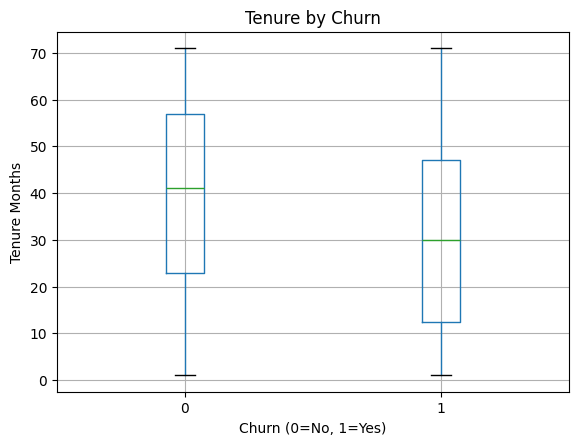

<Figure size 640x480 with 0 Axes>

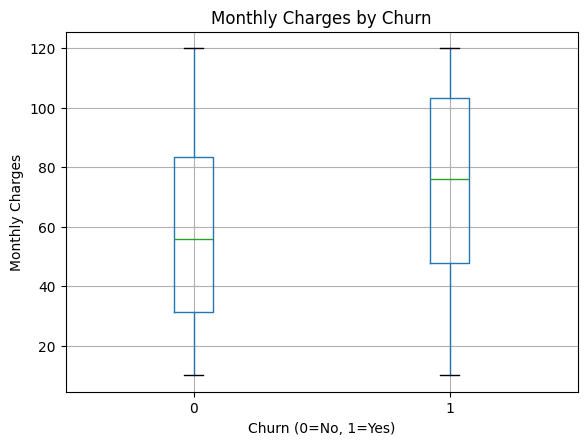

In [6]:
# tenure vs churn
plt.figure()
df.boxplot(column="tenure_months", by="churn")
plt.title("Tenure by Churn")
plt.suptitle("")
plt.xlabel("Churn (0=No, 1=Yes)")
plt.ylabel("Tenure Months")
plt.show()

# monthly charges vs churn
plt.figure()
df.boxplot(column="monthly_charges", by="churn")
plt.title("Monthly Charges by Churn")
plt.suptitle("")
plt.xlabel("Churn (0=No, 1=Yes)")
plt.ylabel("Monthly Charges")
plt.show()


## Step 3: Feature Engineering

I will add:
- **avg_monthly_value** = total_charges / tenure
- **expected_annual_value** = avg_monthly_value × 12

These will support **value-based prioritisation** later.


In [7]:
df = df.copy()
df["avg_monthly_value"] = df["total_charges"] / (df["tenure_months"] + 1)
df["expected_annual_value"] = df["avg_monthly_value"] * 12

df[["tenure_months", "monthly_charges", "total_charges", "avg_monthly_value", "expected_annual_value"]].head()


,tenure_months,monthly_charges,total_charges,avg_monthly_value,expected_annual_value
0,7,38.64,284.20,35.525000,426.300000
1,55,45.47,2423.15,43.270536,519.246429
2,47,36.67,1736.12,36.169167,434.030000
3,32,62.78,2006.67,60.808182,729.698182
4,31,85.16,2646.46,82.701875,992.422500


## Step 4: Train/Test Split + Modelling

I will compare:
- Logistic Regression (interpretable baseline)
- Random Forest (bagging ensemble)
- Gradient Boosting (strong benchmark model)

Metrics:
- ROC-AUC (robust for imbalanced classification)
- Accuracy, Precision, Recall, F1
- Confusion Matrix


In [8]:
target = "churn"

# Features
X = df.drop(columns=[target])
y = df[target]

# Define numeric vs categorical
numeric_features = ["tenure_months", "monthly_charges", "total_charges", "support_tickets", "avg_monthly_value", "expected_annual_value"]
categorical_features = ["contract_type", "payment_method"]

preprocess = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train.shape, X_test.shape


((1200, 9), (300, 9))

In [9]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
}

results = []

fitted_models = {}

for name, model in models.items():
    clf = Pipeline(steps=[("preprocess", preprocess), ("model", model)])
    clf.fit(X_train, y_train)

    probs = clf.predict_proba(X_test)[:, 1]
    preds = (probs >= 0.5).astype(int)

    metrics = {
        "model": name,
        "roc_auc": roc_auc_score(y_test, probs),
        "accuracy": accuracy_score(y_test, preds),
        "precision": precision_score(y_test, preds, zero_division=0),
        "recall": recall_score(y_test, preds, zero_division=0),
        "f1": f1_score(y_test, preds, zero_division=0),
    }
    results.append(metrics)
    fitted_models[name] = clf

results_df = pd.DataFrame(results).sort_values("roc_auc", ascending=False)
results_df


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,model,roc_auc,accuracy,precision,recall,f1
0,Logistic Regression,0.768017,0.716667,0.691589,0.587302,0.635193
2,Gradient Boosting,0.702974,0.640000,0.578947,0.523810,0.550000
1,Random Forest,0.692301,0.660000,0.603448,0.555556,0.578512


In [10]:
best_model_name = results_df.iloc[0]["model"]
best_model = fitted_models[best_model_name]

probs = best_model.predict_proba(X_test)[:, 1]
preds = (probs >= 0.5).astype(int)

cm = confusion_matrix(y_test, preds)
print("Best model:", best_model_name)
print("Confusion matrix:\n", cm)
print("\nClassification report:\n")
print(classification_report(y_test, preds, zero_division=0))


Best model: Logistic Regression
Confusion matrix:
 [[141  33]
 [ 52  74]]

Classification report:

              precision    recall  f1-score   support

           0       0.73      0.81      0.77       174
           1       0.69      0.59      0.64       126

    accuracy                           0.72       300
   macro avg       0.71      0.70      0.70       300
weighted avg       0.71      0.72      0.71       300



## Step 5: Value-based Retention Prioritisation

In consulting, predictive performance is not enough: the goal is to **support decisions**.

Therefore, I will create:
- churn_risk = predicted probability of churn
- priority_score = churn_risk × expected_annual_value

This approximates where retention effort may produce the most value.


In [11]:
df_scored = df.copy()

df_scored["churn_risk"] = best_model.predict_proba(X)[:, 1]
df_scored["priority_score"] = df_scored["churn_risk"] * df_scored["expected_annual_value"]

top_targets = df_scored.sort_values("priority_score", ascending=False).head(20)
top_targets[["customer_id", "churn_risk", "expected_annual_value", "priority_score", "contract_type", "support_tickets"]]


,customer_id,churn_risk,expected_annual_value,priority_score,contract_type,support_tickets
99,100,0.862026,1376.596364,1186.661737,Month-to-month,3
1238,1239,0.835538,1409.608696,1177.781419,Month-to-month,3
230,231,0.861992,1351.023529,1164.570811,Month-to-month,4
868,869,0.823728,1388.203636,1143.502788,Month-to-month,3
334,335,0.812071,1366.115294,1109.383019,Month-to-month,3
87,88,0.837424,1318.985000,1104.550079,Month-to-month,3
1414,1415,0.853229,1291.540465,1101.979492,Month-to-month,5
379,380,0.799448,1365.492000,1091.639609,Month-to-month,2
633,634,0.789913,1353.831429,1069.408874,Month-to-month,2
772,773,0.780632,1364.880000,1065.468940,Month-to-month,1


In [12]:
import json

# Save metrics
metrics_out = results_df.to_dict(orient="records")
with open("metrics.json", "w") as f:
    json.dump(metrics_out, f, indent=2)

# Save top targets
top_targets.to_csv("high_priority_customers.csv", index=False)

print("Saved: metrics.json and high_priority_customers.csv")


Saved: metrics.json and high_priority_customers.csv


## Limitations & Next Steps (Professional Reflection)

- **Data quality**: churn labels and customer attributes often contain missingness and bias.
- **Threshold tuning**: 0.5 may not be optimal; choose a threshold that matches business costs (false positives vs false negatives).
- **Deployment**: integrate into CRM workflows; monitor drift and recalibrate regularly.
- **Ethics**: avoid unfair targeting; ensure explainability for stakeholders.
